---
title: "Can the FED Control Inflation and Maintain Employment?"
subtitle: "DATA 608 Spring 2025 - Story 2"
author: "Stephanie Chiang"
format: revealjs
jupyter: python3
execute:
  echo: true
---

## Introduction

This analysis will be focused on the 25 year period from 1999 to 2024. From the Bureau of Labor Statistics, we will be using the Consumer Price Index (CPI) and raw unemployment numbers. From the Federal Reserve, data has been taken on the Federal Funds Rate (FRED).

## Data

The CPI is given as a number representing the average change in the price of goods in each period compared to the base of 100 set in 1982. SO, a CPI of 150 would mean that the average price of goods and services increased by 50% from that base. The unemployment data is given as the number of reported unemployed people in the thousands. The Federal Funds Rate is given as the interest rate percentage, and is set by the FED.

In [2]:
#| echo: false
#| output: false

import pandas as pd
import numpy as np

# Import the CPI data
cpi_raw = pd.read_excel("cpiu.xlsx")

# Import the FRED data
fred_raw = pd.read_csv("FEDFUNDS.csv")

# Import the unemployment data
unem_raw = pd.read_excel("unemployment.xlsx")

/Users/stephchiang/Library/Python/3.9/lib/python/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")
/Users/stephchiang/Library/Python/3.9/lib/python/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [3]:
#| echo: false
#| output: false

# Select and clean up the CPI data
cpi = cpi_raw.copy()

cpi = cpi.iloc[10:, :-2]
cpi.columns = cpi.iloc[0]
cpi = cpi[1:].reset_index(drop=True)

# pivot the data longer so each observation is a year-month pair
cpi = cpi.melt(id_vars=["Year"], var_name="month", value_name="CPI")

# convert the month to a number and combine into a datetime object
cpi["month"] = pd.to_datetime(cpi["month"], format="%b").dt.month
cpi["date"] = pd.to_datetime(cpi[["Year", "month"]].assign(day=1))
cpi = cpi.drop(columns=["Year", "month"])

# convert the CPI to numeric
cpi["CPI"] = pd.to_numeric(cpi["CPI"], errors="coerce")

print(cpi.head())

     CPI       date
0  175.3 1999-01-01
1  178.8 2000-01-01
2  183.5 2001-01-01
3  188.2 2002-01-01
4  191.8 2003-01-01


In [4]:
#| echo: false
#| output: false

# Select and clean up the unemployment data
unem = unem_raw.copy()

unem = unem.iloc[10:]
unem.columns = unem.iloc[0]
unem = unem[1:].reset_index(drop=True)

# pivot the data longer so each observation is a year-month pair
unem = unem.melt(id_vars=["Year"], var_name="month", value_name="unemployment")

# convert the month to a number and combine into a datetime object
unem["month"] = pd.to_datetime(unem["month"], format="%b").dt.month
unem["date"] = pd.to_datetime(unem[["Year", "month"]].assign(day=1))
unem = unem.drop(columns=["Year", "month"])

# convert the unemployment column to numeric
unem["unemployment"] = pd.to_numeric(unem["unemployment"], errors="coerce")

print(unem.head())

   unemployment       date
0          5976 1999-01-01
1          5708 2000-01-01
2          6023 2001-01-01
3          8182 2002-01-01
4          8520 2003-01-01


In [5]:
#| echo: false
#| output: false

# Select and clean up the FRED data
fred = fred_raw.copy()

# convert the observation_date column to a datetime object
fred["date"] = pd.to_datetime(fred["observation_date"])
fred = fred.drop(columns=["observation_date"])

print(fred.head())

   FEDFUNDS       date
0      4.63 1999-01-01
1      4.76 1999-02-01
2      4.81 1999-03-01
3      4.74 1999-04-01
4      4.74 1999-05-01


In [6]:
#| echo: false
#| output: false

# Join all three dataframes together on the date column and sort
df = cpi.merge(unem, on="date").merge(fred, on="date")
df = df.sort_values(by="date").reset_index(drop=True)

print(df.head())

     CPI       date  unemployment  FEDFUNDS
0  175.3 1999-01-01          5976      4.63
1  175.7 1999-02-01          6111      4.76
2  176.2 1999-03-01          5783      4.81
3  176.8 1999-04-01          6004      4.74
4  176.6 1999-05-01          5796      4.74


---

### Has the Federal Reserve been able to fulfill the mandate given to it by Congress to control inflation and maintain maxiumum employment?

To visualize this more effectively, the data will have to be transformed. Since each of the three variables is represented in a different unit, we can standardize the data for comparison on the same scale by calculating the z-score for each of the columns. This will allow us to plot the standard deviation from the mean for each data point.

---

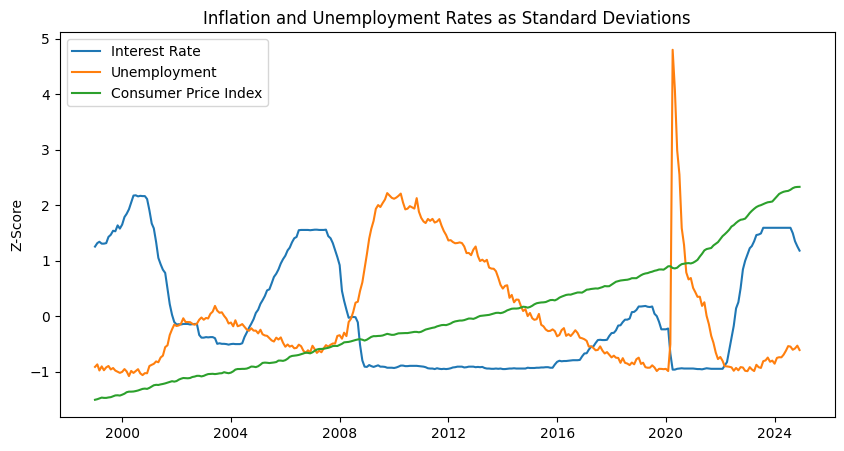

In [7]:
#| output-location: slide

import seaborn as sns
import matplotlib.pyplot as plt
from math import sqrt
from scipy.stats import zscore

# standardize the data using Z-score normalization
df_stand = df.copy()
df_stand[["FEDFUNDS", "CPI", "unemployment"]] = df[["FEDFUNDS", "CPI", "unemployment"]].apply(zscore)

# plot the standardized data
plt.figure(figsize=(10, 5))
sns.lineplot(data=df_stand, x="date", y="FEDFUNDS", label="Interest Rate")
sns.lineplot(data=df_stand, x="date", y="unemployment", label="Unemployment")
sns.lineplot(data=df_stand, x="date", y="CPI", label="Consumer Price Index")

plt.title("Inflation and Unemployment Rates as Standard Deviations")
plt.xlabel("")
plt.ylabel("Z-Score")

plt.show()

---

In the line plot, the FED's interest rate appears to have little effect on the CPI. The CPI has steadily increased since the start of our data in 1999, with only a noticeble sharper increase after 2020. The other two variables fluctuate; it may appear that the interest rate and the unemployment rate are inversely related, with the interest rate decreasing as the unemployment rate increases. The correlation plots below can show this relationship more clearly.

---

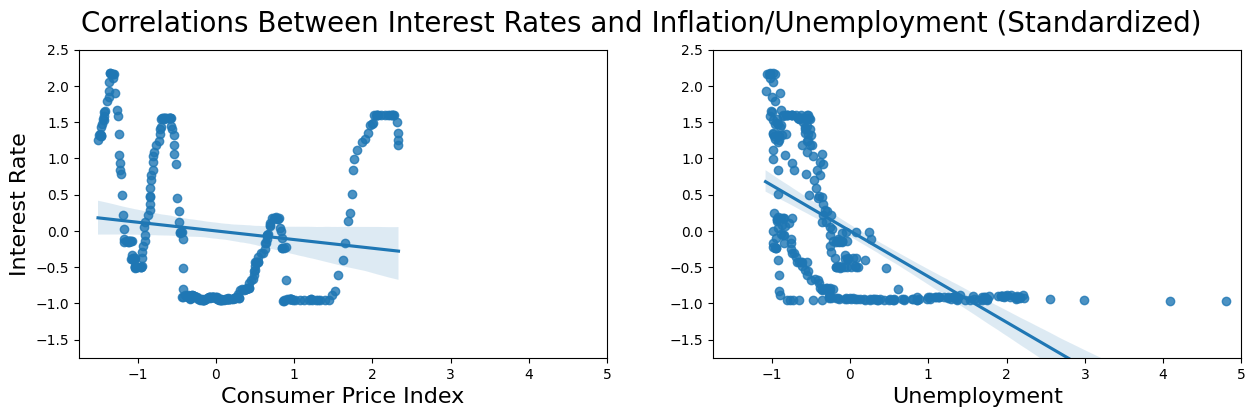

In [8]:
#| output-location: slide

fig, axs = plt.subplots(figsize=(15, 4), ncols = 2)

sns.regplot(
  data = df_stand,
  x = "CPI",
  y = "FEDFUNDS",
  ax = axs[0],
)
axs[0].set_xlim(-1.75, 5)
axs[0].set_ylim(-1.75, 2.5)
axs[0].set_xlabel("Consumer Price Index", fontsize=16)
axs[0].set_ylabel("Interest Rate", fontsize=16)

sns.regplot(
  data = df_stand,
  x = "unemployment",
  y = "FEDFUNDS",
  ax = axs[1],
)
axs[1].set_xlim(-1.75, 5)
axs[1].set_ylim(-1.75, 2.5)
axs[1].set_xlabel("Unemployment", fontsize=16)
axs[1].set_ylabel("")

fig.suptitle("Correlations Between Interest Rates and Inflation/Unemployment (Standardized)", fontsize=20)

plt.show()

---

Based on the previous plots, it would be difficult to say if the Federal Reserve has had any effect on the prices of consumer goods, used here as the measure of inflation. The link between the the Fed's control of the interest rate and unemployment numbers is more plausible but not definitively causal (and possibly only reactionary).

Therefore, it can be concluded that the Federal Reserve has not been able to fulfill the dual mandate of maximum employment and stabilizing inflation.